In [3]:
import geopandas as gpd
import pandas as pd

# Cargar el KML
gdf = gpd.read_file("../data/raw/MUI_ZMG.kml", driver="KML")

# Diagnóstico básico
print("Filas:", gdf.shape[0])
print("Columnas:", gdf.columns.tolist())
print("\nTipos de geometría:")
print(gdf.geometry.geom_type.value_counts())
print("\nCRS:", gdf.crs)
print("\nPrimeras filas:")
# gdf.head()

Filas: 188
Columnas: ['id', 'Name', 'description', 'timestamp', 'begin', 'end', 'altitudeMode', 'tessellate', 'extrude', 'visibility', 'drawOrder', 'icon', 'nombre', 'descripci__n', 'Altura_m__xima_reportada', 'Motivo', 'Infraestructura_expuesta', 'geometry']

Tipos de geometría:
Polygon    188
Name: count, dtype: int64

CRS: EPSG:4326

Primeras filas:


c:\Users\MAGI\Desktop\hidro-zmg\.venv\Lib\site-packages\pyogrio\geopandas.py:382: UserWarning: More than one layer found in 'MUI_ZMG.kml': 'Zonas Criticas' (default), 'Sitios Inundales', 'Categoría'. Specify layer parameter to avoid this warning.
  result = read_func(


In [4]:
import geopandas as gpd
import pandas as pd

capas = ['Zonas Criticas', 'Sitios Inundales', 'Categoría']
gdfs  = {}

for capa in capas:
    gdf = gpd.read_file("../data/raw/MUI_ZMG.kml", driver="KML", layer=capa)
    gdf["_capa_origen"] = capa
    gdfs[capa] = gdf
    print(f"\n-- {capa} --")
    print(f"  Filas: {len(gdf)}")
    print(f"  Geometrías: {gdf.geometry.geom_type.value_counts().to_dict()}")


-- Zonas Criticas --
  Filas: 188
  Geometrías: {'Polygon': 188}

-- Sitios Inundales --
  Filas: 310
  Geometrías: {'Polygon': 310}

-- Categoría --
  Filas: 310
  Geometrías: {'Point': 310}


In [ ]:
cols_interes = ['nombre', 'descripci__n', 'Motivo',
                'Infraestructura_expuesta', 'Altura_m__xima_reportada', '_capa_origen']

for nombre_capa, gdf in gdfs.items():
    print(f"\n{'-------------'}")
    print(f"CAPA: {nombre_capa}")
    cols_presentes = [c for c in cols_interes if c in gdf.columns]
    print(gdf[cols_presentes].head(4).to_string())
    
    # Valores únicos de columnas categóricas
    for col in ['Motivo', 'Infraestructura_expuesta']:
        if col in gdf.columns:
            print(f"\n  [{col}] valores únicos:")
            print(" ", gdf[col].value_counts(dropna=False).to_dict())


--------------------------------------------------
CAPA: Zonas Criticas
  nombre descripci__n                Motivo Infraestructura_expuesta Altura_m__xima_reportada    _capa_origen
0                       Ingreso a inmuebles                 Vivienda                      200  Zonas Criticas
1                       Ingreso a inmuebles                 Vivienda                      150  Zonas Criticas
2                       Ingreso a inmuebles                 Vivienda                      160  Zonas Criticas
3                      Altura de inundación   Paso desnivel inferior                       60  Zonas Criticas

  [Motivo] valores únicos:
  {'Ingreso a inmuebles': 115, 'Fuerza de la corriente': 14, 'Altura de la inundación': 6, 'Ingreso a inmueble': 6, 'Inundación en paso a desnivel': 5, 'Profundidad de la inundación': 4, 'Fuerza de la corriente, Ingreso a inmuebles': 4, 'Profundidad mayor a un encharcamiento': 4, 'Ingreso a vivienda': 3, 'Profunidad de la inundación': 3, 'Vialidad

In [6]:
# Unir las 3 capas en un solo GeoDataFrame
gdf_mui = gpd.GeoDataFrame(
    pd.concat(gdfs.values(), ignore_index=True)
)

# Reproyectar a UTM Zona 14N (unidades en metros)
gdf_mui = gdf_mui.to_crs("EPSG:32614")

# Calcular área de cada polígono en m^2
gdf_mui["area_m2"] = gdf_mui.geometry.area

# Guardar el GeoPackage procesado
gdf_mui.to_file("../data/processed/MUI_unificado.gpkg", driver="GPKG")

print(f"Total polígonos unificados: {len(gdf_mui)}")
print(f"\nDistribución por capa:")
print(gdf_mui["_capa_origen"].value_counts())
print(f"\nÁrea de inundación mínima: {gdf_mui['area_m2'].min():.1f} m²")
print(f"Área de inundación máxima: {gdf_mui['area_m2'].max():.1f} m²")
print(f"Área total catalogada:     {gdf_mui['area_m2'].sum()/1e6:.3f} km²")

Total polígonos unificados: 808

Distribución por capa:
_capa_origen
Sitios Inundales    310
Categoría           310
Zonas Criticas      188
Name: count, dtype: int64

Área de inundación mínima: 0.0 m²
Área de inundación máxima: 6484577.6 m²
Área total catalogada:     25.685 km²


In [ ]:
import folium

colores = {
    'Zonas Criticas': '#D9534F',
    'Sitios Inundales': '#F0AD4E',
    'Categoría': '#5BC0DE'
}

m = folium.Map(location=[20.67, -103.35], zoom_start=11,
               tiles="CartoDB dark_matter")

for nombre_capa, gdf in gdfs.items():
    gdf_4326 = gdf.to_crs("EPSG:4326")
    folium.GeoJson(
        gdf_4326,
        name=nombre_capa,
        style_function=lambda x, c=colores[nombre_capa]: {
            "fillColor": c, "color": c,
            "weight": 1, "fillOpacity": 0.5
        },
        tooltip=folium.GeoJsonTooltip(
            fields=[f for f in ['nombre', 'Motivo', 'Infraestructura_expuesta']
                    if f in gdf_4326.columns]
        )
    ).add_to(m)

folium.LayerControl().add_to(m)
m.save("../data/processed/MUI_diagnostico.html")
m

In [10]:
import re

# Diccionario de normalización para Motivo
mapa_motivo = {
    # Ingreso a inmuebles
    'ingreso a inmuebles': 'Ingreso a inmueble',
    'ingreso a inmueble': 'Ingreso a inmueble',
    'ingreso a vivienda': 'Ingreso a inmueble',
    'ingreso a inmueble, por desborde del acueducto': 'Ingreso a inmueble',
    'ingreso a inmueble, desborde la presa el chicharrón': 'Ingreso a inmueble',
    'altura mayor a un encharcamiento, ingreso a inmuebles': 'Ingreso a inmueble',
    'ingreso a inmuebles, vialidad': 'Ingreso a inmueble',
    'aguas negras, ingreso a inmuebles': 'Ingreso a inmueble',
    # Fuerza de corriente
    'fuerza de la corriente': 'Fuerza de corriente',
    'fuerza de la corriente, ingreso a inmuebles': 'Fuerza de corriente',
    'fuerza de la corriente, ingreso a inmueble': 'Fuerza de corriente',
    'ingreso a inmuebles, fuerza de la corriente': 'Fuerza de corriente',
    'ingreso a inmuebles, fuerza la corriente': 'Fuerza de corriente',
    'altura de la inundación, fuerza de la corriente': 'Fuerza de corriente',
    'fuerza y profundidad de la corriente': 'Fuerza de corriente',
    'crecida súbita con gran fueza de arrastre': 'Fuerza de corriente',
    # Profundidad / altura
    'altura de la inundación': 'Profundidad crítica',
    'altura de inundación': 'Profundidad crítica',
    'altura': 'Profundidad crítica',
    'profundidad de la inundación': 'Profundidad crítica',
    'profunidad de la inundación': 'Profundidad crítica',
    'profundidad mayor a un encharcamiento': 'Profundidad crítica',
    'profundidad': 'Profundidad crítica',
    'profundidad y velocidad de la corriente': 'Profundidad crítica',
    'profundidad y fuerza de la corriente': 'Profundidad crítica',
    'profunidad y fuerza de la corriente': 'Profundidad crítica',
    'profunidad y fuerza de la corriente. ingresos destapados': 'Profundidad crítica',
    # Paso desnivel 
    'inundación en paso a desnivel': 'Profundidad crítica',
    # Vialidad
    'vialidad': 'Afectación vial',
    'vehículos varados': 'Afectación vial',
    'accidentes automolisticos por las condiciones': 'Afectación vial',
    # Aguas negras
    'aguas negras': 'Aguas negras',
}

# Diccionario de normalización para Infraestructura_expuesta
mapa_infra = {
    # Vivienda
    'vivienda': 'Vivienda',
    'viviendas': 'Vivienda',
    'viviendo': 'Vivienda',
    'vivienda, equipamiento': 'Vivienda',
    'vivienda, vialidad': 'Vivienda',
    'vialidad, vivienda': 'Vivienda',
    'vivienda y negocios': 'Vivienda',
    'ingreso a viviendas, negocios': 'Vivienda',
    'vivienda, vialidades': 'Vivienda',
    'vialidades, vivienda': 'Vivienda',
    'vivienda, vialidad, equipamiento': 'Vivienda',
    'vivienda, gasolinera, plaza comercial': 'Vivienda',
    'vivienda, propiedad provada': 'Vivienda',
    'debilita la estructura de las viviendas': 'Vivienda',
    'escuela, vivienda': 'Vivienda',
    'negocios': 'Vivienda',
    # Vialidad
    'vialidad': 'Vialidad',
    'vialidad, inmuebles': 'Vialidad',
    'vialidad, transporte público': 'Vialidad',
    'vialidad, pero con riesgo de arrastre': 'Vialidad',
    'plaza y vialidad': 'Vialidad',
    'vialidad, gasolinera': 'Vialidad',
    # Paso desnivel
    'paso desnivel inferior': 'Paso desnivel inferior',
    'paso a desnivel': 'Paso desnivel inferior',
    'paso desnivel inferior': 'Paso desnivel inferior',
    # Equipamiento
    'equipamiento': 'Equipamiento',
    'inmuebles, equipamiento': 'Equipamiento',
    'telesecundaria': 'Equipamiento',
    'industria': 'Equipamiento',
    'plaza y vialidad': 'Equipamiento',
}

def normalizar(valor, mapa):
    if pd.isna(valor) or valor == '':
        return 'Sin dato'
    return mapa.get(valor.strip().lower(), valor.strip())

# Aplicar normalización solo a Zonas Criticas
gdf_zc = gdfs['Zonas Criticas'].copy()
gdf_zc['motivo_norm'] = gdf_zc['Motivo'].apply(lambda x: normalizar(x, mapa_motivo))
gdf_zc['infra_norm'] = gdf_zc['Infraestructura_expuesta'].apply(lambda x: normalizar(x, mapa_infra))
gdf_zc['altura_cm'] = pd.to_numeric(gdf_zc['Altura_m__xima_reportada'], errors='coerce')

print("Motivo normalizado:")
print(gdf_zc['motivo_norm'].value_counts())
print("\nInfraestructura normalizada:")
print(gdf_zc['infra_norm'].value_counts())
print("\nAltura (cm) - estadísticas:")
print(gdf_zc['altura_cm'].describe())

Motivo normalizado:
motivo_norm
Ingreso a inmueble     130
Profundidad crítica     29
Fuerza de corriente     24
Afectación vial          4
Aguas negras             1
Name: count, dtype: int64

Infraestructura normalizada:
infra_norm
Vivienda                  130
Vialidad                   37
Paso desnivel inferior     10
Equipamiento               10
Sin dato                    1
Name: count, dtype: int64

Altura (cm) - estadísticas:
count    181.000000
mean      93.038674
std       78.758729
min       10.000000
25%       40.000000
50%       70.000000
75%      120.000000
max      600.000000
Name: altura_cm, dtype: float64


In [11]:
# Clasificación de riesgo basada en altura + motivo + infraestructura
def clasificar_riesgo(row):
    altura = row['altura_cm']
    motivo = row['motivo_norm']
    infra  = row['infra_norm']

    # Riesgo CRÍTICO
    if (altura >= 150 or
        'Fuerza de corriente' in motivo or
        'Paso a desnivel' in motivo or
        infra == 'Paso desnivel inferior'):
        return 'Crítico'

    # Riesgo ALTO
    if (altura >= 80 or
        'Profundidad crítica' in motivo or
        infra == 'Vialidad'):
        return 'Alto'

    # Riesgo MEDIO
    if altura >= 30:
        return 'Medio'

    # Riesgo BAJO
    return 'Bajo'

gdf_zc['riesgo'] = gdf_zc.apply(clasificar_riesgo, axis=1)

print("Distribución de clases de riesgo:")
print(gdf_zc['riesgo'].value_counts())
print(f"\nBalance de clases: {gdf_zc['riesgo'].value_counts(normalize=True).mul(100).round(1).to_dict()}")

Distribución de clases de riesgo:
riesgo
Crítico    65
Medio      50
Alto       46
Bajo       27
Name: count, dtype: int64

Balance de clases: {'Crítico': 34.6, 'Medio': 26.6, 'Alto': 24.5, 'Bajo': 14.4}


In [12]:
def recomendar_intervencion(row):
    infra   = row['infra_norm']
    motivo  = row['motivo_norm']
    riesgo  = row['riesgo']
    altura  = row['altura_cm']

    if infra == 'Paso desnivel inferior':
        return {
            'intervencion': 'Bioswale peatonal + rejilla de captación',
            'descripcion': 'Canal de biorretención lateral con rejilla de desvío de escorrentía vial',
            'area_captacion_est_m2': row['geometry'].area * 2.5,
            'cobeneficios': 'Reduce velocidad de flujo, filtra contaminantes viales'
        }
    elif infra == 'Vivienda' and riesgo in ['Crítico', 'Alto']:
        return {
            'intervencion': 'Jardín de lluvia en banqueta',
            'descripcion': 'Depresión plantada en derecho de vía para capturar escorrentía de techos y vialidad',
            'area_captacion_est_m2': row['geometry'].area * 1.8,
            'cobeneficios': 'Recarga de acuífero, reducción de temperatura superficial, hábitat urbano'
        }
    elif infra == 'Vialidad' and 'Fuerza de corriente' in motivo:
        return {
            'intervencion': 'Pavimento permeable + árbol de lluvia',
            'descripcion': 'Sustitución de pavimento impermeable con sistema de árbol estructural tipo Silva Cell',
            'area_captacion_est_m2': row['geometry'].area * 3.0,
            'cobeneficios': 'Reduce velocidad de escorrentía, sombra urbana, captura de carbono'
        }
    elif riesgo == 'Crítico' and altura >= 150:
        return {
            'intervencion': 'Parque inundable (retention basin)',
            'descripcion': 'Espacio público de uso mixto diseñado para retener agua en eventos extremos',
            'area_captacion_est_m2': row['geometry'].area * 5.0,
            'cobeneficios': 'Mayor capacidad de retención, espacio recreativo, conectividad ecológica'
        }
    else:
        return {
            'intervencion': 'Cuneta verde',
            'descripcion': 'Franja vegetada lateral para conducción lenta de escorrentía',
            'area_captacion_est_m2': row['geometry'].area * 1.2,
            'cobeneficios': 'Mejora calidad del agua, reduce velocidad de escorrentía'
        }

intervenciones = gdf_zc.apply(recomendar_intervencion, axis=1, result_type='expand')
gdf_zc = pd.concat([gdf_zc, intervenciones], axis=1)

print("Distribución de intervenciones recomendadas:")
print(gdf_zc['intervencion'].value_counts())

Distribución de intervenciones recomendadas:
intervencion
Cuneta verde                                92
Jardín de lluvia en banqueta                57
Pavimento permeable + árbol de lluvia       16
Parque inundable (retention basin)          13
Bioswale peatonal + rejilla de captación    10
Name: count, dtype: int64


In [13]:
# Reproyectar y guardar
gdf_zc = gdf_zc.to_crs("EPSG:32614")
gdf_zc['area_m2'] = gdf_zc.geometry.area

cols_guardar = ['nombre', 'motivo_norm', 'infra_norm', 'altura_cm',
                'riesgo', 'intervencion', 'descripcion',
                'area_captacion_est_m2', 'cobeneficios', 'area_m2', 'geometry']

gdf_zc[cols_guardar].to_file("../data/processed/ZonasCriticas_limpio.gpkg", driver="GPKG")
print(f"Dataset guardado: {len(gdf_zc)} polígonos listos para modelado")

Dataset guardado: 188 polígonos listos para modelado


Distribución de altura_cm:
count    181.000000
mean      93.038674
std       78.758729
min       10.000000
25%       40.000000
50%       70.000000
75%      120.000000
max      600.000000
Name: altura_cm, dtype: float64

Percentiles clave:
  P25: 40 cm
  P50: 70 cm
  P75: 120 cm
  P90: 200 cm


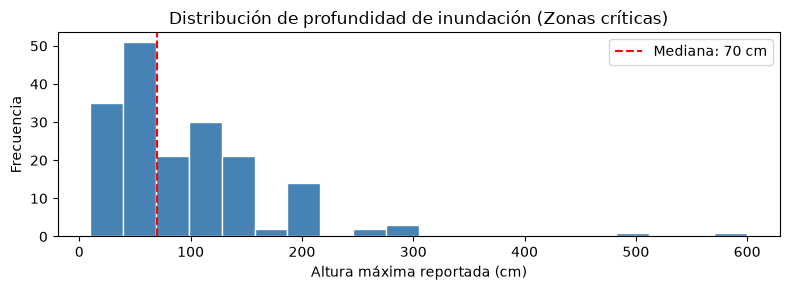

In [14]:
import numpy as np

# Ver la distribución real de alturas
alturas = gdf_zc['altura_cm'].dropna().sort_values()

print("Distribución de altura_cm:")
print(alturas.describe())
print("\nPercentiles clave:")
for p in [25, 50, 75, 90]:
    print(f"  P{p}: {np.percentile(alturas, p):.0f} cm")

# Histograma rápido
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 3))
plt.hist(alturas, bins=20, color='steelblue', edgecolor='white')
plt.axvline(alturas.median(), color='red', linestyle='--', label=f'Mediana: {alturas.median():.0f} cm')
plt.xlabel("Altura máxima reportada (cm)")
plt.ylabel("Frecuencia")
plt.title("Distribución de profundidad de inundación (Zonas críticas)")
plt.legend()
plt.tight_layout()
plt.savefig("../data/processed/distribucion_altura.png", dpi=150)
plt.show()

In [15]:
# Riesgo_CENAPRED (basado en la norma oficial de CENAPRED)
def riesgo_cenapred(altura_cm):
    if pd.isna(altura_cm):
        return 'Sin dato'
    if altura_cm < 50:
        return 'Bajo'
    elif altura_cm < 100:
        return 'Medio'
    elif altura_cm < 200:
        return 'Alto'
    else:
        return 'Crítico'

gdf_zc['riesgo_cenapred'] = gdf_zc['altura_cm'].apply(riesgo_cenapred)

# Riesgo_compuesto (altura + motivo + infraestructura)

print("Riesgo CENAPRED (solo altura):")
print(gdf_zc['riesgo_cenapred'].value_counts())
print("\nRiesgo compuesto (altura + motivo + infraestructura):")
print(gdf_zc['riesgo'].value_counts())

Riesgo CENAPRED (solo altura):
riesgo_cenapred
Medio       54
Alto        53
Bajo        53
Crítico     21
Sin dato     7
Name: count, dtype: int64

Riesgo compuesto (altura + motivo + infraestructura):
riesgo
Crítico    65
Medio      50
Alto       46
Bajo       27
Name: count, dtype: int64


In [17]:
# Registros con alturas extremas
print("-- Outliers (altura > 300 cm) --")
outliers = gdf_zc[gdf_zc['altura_cm'] > 300][
    ['nombre', 'motivo_norm', 'infra_norm', 'altura_cm']
]
print(outliers.to_string())

print("\n-- Sin dato de altura --")
sin_dato = gdf_zc[gdf_zc['altura_cm'].isna()][
    ['nombre', 'motivo_norm', 'infra_norm']
]
print(sin_dato.to_string())

-- Outliers (altura > 300 cm) --
    nombre          motivo_norm              infra_norm  altura_cm
9           Profundidad crítica  Paso desnivel inferior      600.0
144          Ingreso a inmueble                Vivienda      500.0

-- Sin dato de altura --
    nombre         motivo_norm infra_norm
8           Ingreso a inmueble   Vivienda
88          Ingreso a inmueble   Vivienda
130               Aguas negras   Vivienda
131         Ingreso a inmueble   Vivienda
134         Ingreso a inmueble   Vivienda
137         Ingreso a inmueble   Vivienda
138         Ingreso a inmueble   Vivienda


In [19]:
# Umbrales ajustados a la distribución real + norma CENAPRED
# P25=30cm, Mediana=70cm, P75=120cm

def riesgo_final(row):
    altura  = row['altura_cm']
    motivo  = row['motivo_norm']
    infra   = row['infra_norm']

    # Sin dato, entonces imputar por infraestructura expuesta
    if pd.isna(altura):
        if infra == 'Paso desnivel inferior':
            return 'Alto'
        elif infra == 'Vivienda':
            return 'Medio'
        else:
            return 'Bajo'

    # Base CENAPRED ajustada a distribución local
    if altura < 50:
        nivel = 'Bajo'
    elif altura < 100:
        nivel = 'Medio'
    elif altura < 200:
        nivel = 'Alto'
    else:
        nivel = 'Crítico'

    # Modificadores por contexto, es decir escalan el riesgo un nivel si hay evidencia de peligro adicional
    if infra == 'Paso desnivel inferior' and nivel == 'Medio':
        nivel = 'Alto'
    if 'Fuerza de corriente' in motivo and nivel == 'Alto':
        nivel = 'Crítico'
    if 'Aguas negras' in motivo:
        nivel = 'Crítico'  # riesgo sanitario independiente de altura

    return nivel

gdf_zc['riesgo_final'] = gdf_zc.apply(riesgo_final, axis=1)

print("-- Distribución final del target variable --")
print(gdf_zc['riesgo_final'].value_counts())
print()
print("Justificación de umbrales:")
print("< 50 cm: Bajo (encharcamiento, CENAPRED)")
print("50-100cm: Medio (calzado/rodilla, pérdidas materiales menores)")
print("100-200cm: Alto (daño estructural a inmuebles, CENAPRED)")
print("> 200 cm: Crítico (riesgo de vida, CENAPRED)")
print("+ modificadores por tipo de infraestructura y motivo")

-- Distribución final del target variable --
riesgo_final
Medio      60
Bajo       53
Alto       48
Crítico    27
Name: count, dtype: int64

Justificación de umbrales:
< 50 cm: Bajo (encharcamiento, CENAPRED)
50-100cm: Medio (calzado/rodilla, pérdidas materiales menores)
100-200cm: Alto (daño estructural a inmuebles, CENAPRED)
> 200 cm: Crítico (riesgo de vida, CENAPRED)
+ modificadores por tipo de infraestructura y motivo
